# 🚕 Taxi Dataset Exploratory Data Analysis (EDA)

This notebook explores the NYC Taxi dataset using PySpark.

### Goals:
- Understand dataset structure
- Check missing values
- Analyze distributions
- Visualize key relationships (distance vs fare, trips by hour)

In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Taxi EDA") \
    .getOrCreate()

26/05/02 15:36:17 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## 📂 Load Dataset

We load the raw parquet file and inspect its structure.

In [9]:
df = spark.read.parquet("../data/taxi.parquet")

df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2025-02-01 00:12:18|  2025-02-01 00:32:33|              3|         3.12|         1|                 N|         246|    

## 📊 Dataset Overview

We check number of rows, columns, and schema.

In [10]:
print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

Rows: 3577543
Columns: 20
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



## ❓ Missing Values Check

We count missing values in each column.

In [11]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|         806937|            0|    806937|            806937|           0|    

## ⏱ Feature Engineering

We create new useful features:
- Trip duration (minutes)
- Pickup hour

In [12]:
from pyspark.sql.functions import unix_timestamp, hour

df = df.withColumn(
    "trip_duration",
    (unix_timestamp("tpep_dropoff_datetime") -
     unix_timestamp("tpep_pickup_datetime")) / 60
)

df = df.withColumn("hour", hour("tpep_pickup_datetime"))

## 📉 Convert Sample for Visualization

We convert a sample of the data to Pandas for plotting.

In [13]:
pdf = df.sample(0.1).toPandas()

## 📊 Distance vs Fare Relationship

We visualize how trip distance affects fare amount.

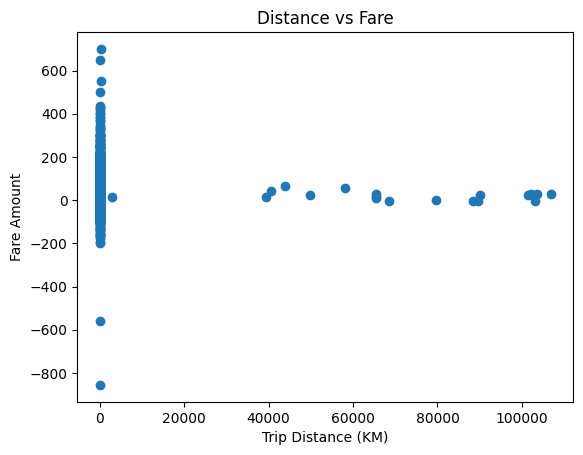

In [15]:

import matplotlib.pyplot as plt

plt.scatter(pdf["trip_distance"], pdf["fare_amount"])
plt.xlabel("Trip Distance (KM)")
plt.ylabel("Fare Amount")
plt.title("Distance vs Fare")
plt.show()

## 🕒 Trips Distribution by Hour

We analyze when most trips happen during the day.

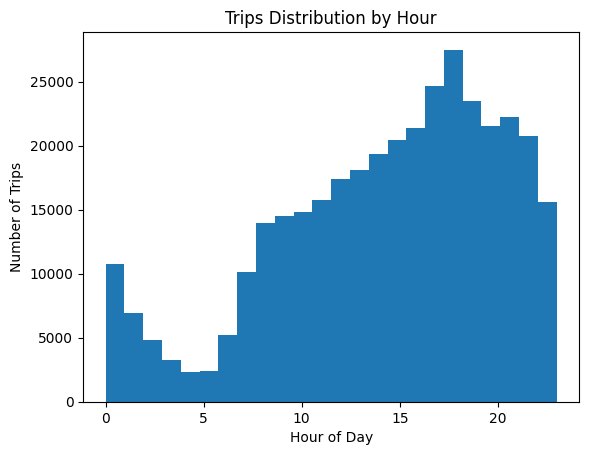

26/05/02 16:41:05 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 721601 ms exceeds timeout 120000 ms
26/05/02 16:41:06 WARN SparkContext: Killing executors is not supported by current scheduler.
26/05/02 16:41:08 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
plt.hist(pdf["hour"], bins=24)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Trips Distribution by Hour")
plt.show()

## 📌 Summary

- Dataset contains taxi trip records
- Strong correlation between distance and fare
- Peak hours show demand patterns
- Feature engineering improves ML readiness